# Лабораторная 1
## Методы дихотомии и золотого сечения
### Задачи
1) График целевой функции
2) Точность eps, количество итераций, количество вычисленных значений целевой функции, точка минимума
3) Графики зависимости ln от n для обоих методов в одной системе координат
### Контрольные вопросы
1) Постановка задачи
2) Алгоритмы методов
3) Сравнение методов

(используем дихотомию для высокой точности)
(используем золотое сечение при тяжелых функциях)

### График целевой функции

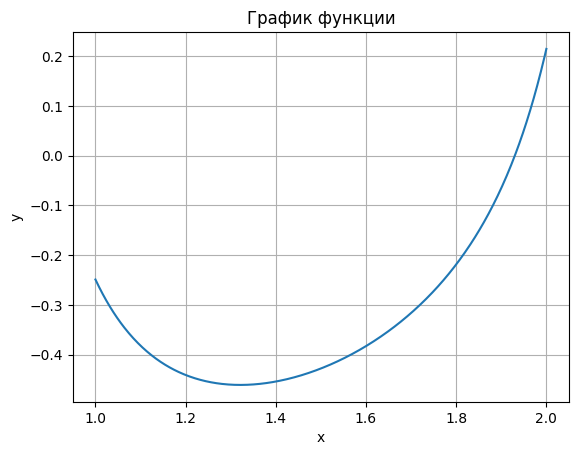

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import math


def f(x):
    global counter
    counter += 1
    R1 = math.atan(x**3 - 5*x + 1)
    R2 = (x**2 / (3*x - 2)) ** math.sqrt(3)
    return R1 + R2

counter = 0
x_list = np.linspace(1, 2, 500)
results = [f(x) for x in x_list]

plt.plot(x_list, results)
plt.title('График функции')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


### Поиск минимума методом дихотомии

In [16]:
# есть a и b, расстояние между ними = l
# если расстояние l <= eps - выход
# берём середину графика l/2
# отсупаем влево и вправо от неё на d получая x1 и x2
# находим y1 = f(x1) и y2 = f(x2)
# если y1 < y2, то b = x2
# если y1 > y2, то a = x1

eps = 0.000001
d = eps / 4

a = 1
b = 2
l = b - a
y1 = 0
y2 = 0

print(f"Точность: {eps}")
print(f"Количество итераций: {math.ceil(math.log2((l-2*d)/(eps-2*d)))}")

counter = 0
while l > eps:
    x0 = a + l / 2
    x1 = x0 - d
    x2 = x0 + d

    y1 = f(x1)
    y2 = f(x2)
    if y1 <= y2:
        b = x2
    else:
        a = x1
    l = b - a


answer = (y1 + y2) / 2
print(f"количество вычисленных значений целевой функции: {counter}")
print(f"{answer:.12f}")

Точность: 1e-06
Количество итераций: 21
количество вычисленных значений целевой функции: 42
-0.460964595934


### Поиск минимума методом золотого сечения

In [ ]:
# есть a и b, расстояние между ними = l
# если расстояние l <= eps - выход
# x1 = b − τ(b − a)
# x2 = a + τ(b − a)
# f(x1) < f(x2) → минимум слева → b=x2
# иначе → минимум справа → a=x1
# отсупаем влево и вправо от неё на d получая x1 и x2
# находим y1 = f(x1) и y2 = f(x2)
# если y1 < y2, то b = x2
# если y1 > y2, то a = x1

eps = 0.000001

a = 1
b = 2
l = b - a
t = (5**0.5 - 1) / 2
x1 = b - t * l
x2 = a + t * l
y1 = f(x1)
y2 = f(x2)

while l > eps:
    if y1 < y2:
        b = x2
        l = b - a
        x2 = x1
        y2 = y1
        x1 = b - t * l
        y1 = f(x1)
    else:
        a = x1
        l = b - a
        x1 = x2
        y1 = y2
        x2 = a + t * l
        y2 = f(x2)
answer = f((a + b) / 2)
print(f"{answer:.12f}")

n: 20.931567847976474
-0.460964595934
